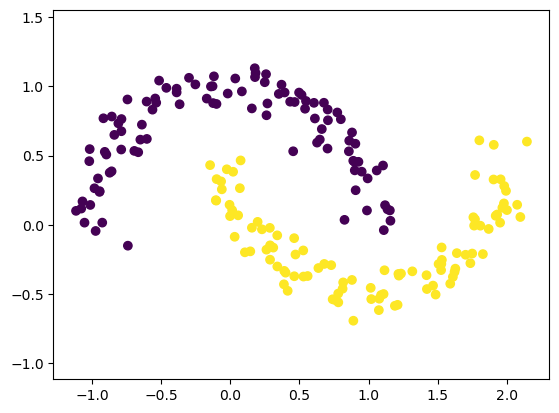

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.1)
# Plot
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.axis('equal')
plt.show()

Mean accuracy: 0.99 ± 0.012


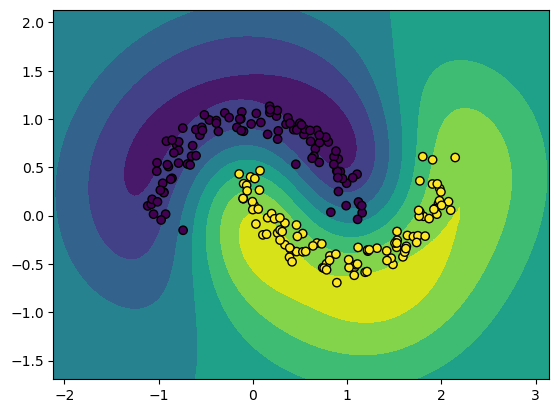

In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.inspection import DecisionBoundaryDisplay

clf = SVC()
scores = cross_val_score(clf, X, y)
print(f"Mean accuracy: {scores.mean():.2g} ± {scores.std():.2g}")

clf.fit(X, y)
DecisionBoundaryDisplay.from_estimator(clf, X)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.show()

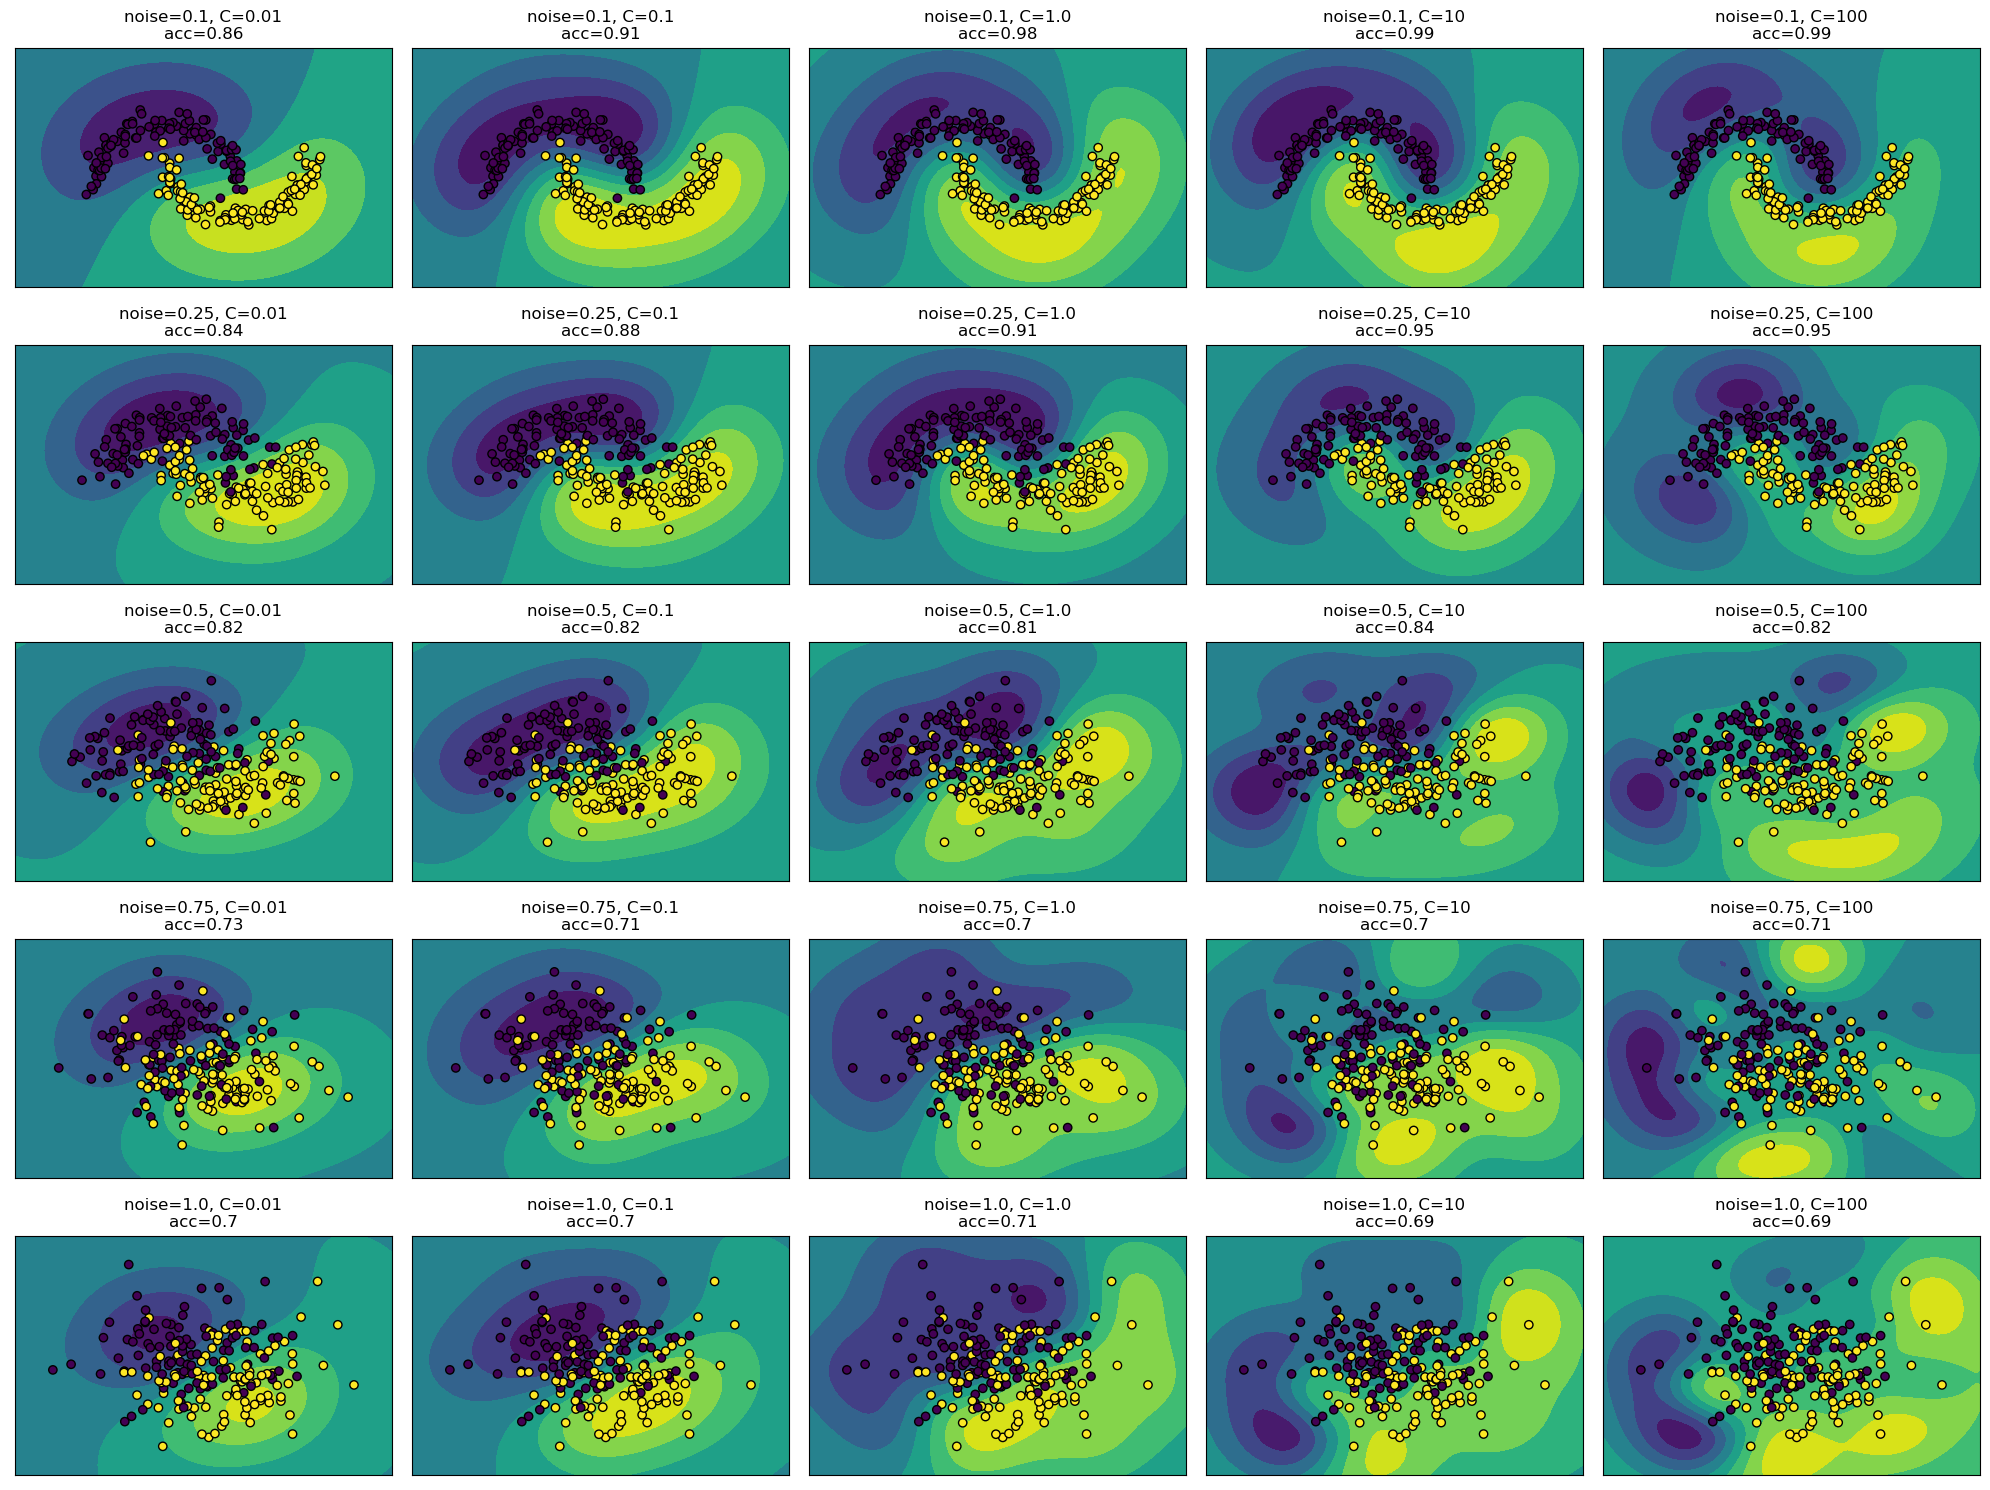

In [28]:
noise_levels = [0.10, 0.25, 0.50, 0.75, 1.00]
C_values = [0.01, 0.1, 1.0, 10, 100]

fig, axes = plt.subplots(5, 5, figsize=(20, 15))
for i, noise in enumerate(noise_levels):
    X, y = make_moons(n_samples=200, noise=noise)
    for j, C in enumerate(C_values):
        ax = axes[i, j]
        clf = SVC(C=C)
        scores = cross_val_score(clf, X, y)
        clf.fit(X, y)
        DecisionBoundaryDisplay.from_estimator(clf, X, ax=ax)
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
        acc = scores.mean()
        ax.set_title(f"noise={noise}, C={C}\nacc={acc:.2g}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()